# Farm Generation Toolchain — *Crop Height and Plot Estimation for Phenotyping from UAVs using 3D LiDAR* (IROS 2020)

Reproduction of **Section V (Farm Generation Toolchain)** of:

> Dhami, Yu, Xu, Zhu, Dhakal, Friel, Li, Tokekar. *Crop Height and Plot Estimation for Phenotyping from Unmanned Aerial Vehicles using 3D LiDAR.* IROS 2020, pp. 2643–2649. [arXiv:1910.14031](https://arxiv.org/abs/1910.14031) / [DOI 10.1109/IROS45743.2020.9341343](https://doi.org/10.1109/IROS45743.2020.9341343)

**Scope: PARTIAL demonstration.** This notebook runs the authors' pinned script
`Python Scripts/farm_generation.py` (commit `b31a54c8dc0b29ecd9aa35df3a6624ef6106eca7` of
[hsd1121/PointCloudProcessing](https://github.com/hsd1121/PointCloudProcessing)) to generate one
randomized Gazebo soybean farm world — a random Delaunay-triangulated terrain, randomly placed /
scaled / rotated plant models, and a per-plot simulated height table — and validates all three
outputs (`generated_ground.dae`, `soy_row.world`, `simulated_heights.csv`).

**Not reproduced here:** the LiDAR height-estimation pipeline (Sections IV, VI) — its ROS/C++/PCL
implementation cannot run in Colab and both released datasets (Kentland Wheat Farm, Gazebo Soybean
Farms) are unreachable (their Google Drive links return HTTP 404, verified during the source
investigation).

**Important provenance notes:**
- The pinned repository contains **no** input files for `farm_generation.py`
  (`ground_params.txt`, `params.txt`, `models.txt`, `3D_Models/height.txt`, `empty.world`,
  `soy.model`). We reconstruct them in this notebook. Parameter values that the paper states
  numerically (3 rows × 10 plots, 90 plants/plot, 150 ground vertices, ±1 m ground variation) are
  taken from the paper (Sec. VI-B, Fig. 10 caption). Values the paper does not state (farm size,
  plot dimensions and spacing, plant scale range, model heights) are **operator-chosen reasonable
  values**, clearly labeled below — the generator is designed to take these as user input.
- The paper's commercial TurboSquid soybean 3D models are **not redistributable and not in the
  repository**, so `models.txt` references placeholder `model://soybean_model_N` URIs. The
  generator only writes URI strings into the world file, so its logic runs faithfully; the mesh
  assets themselves are unavailable. No LICENSE file exists in the repository.

日本語: このノートブックは IROS 2020 論文の第 V 節「ファーム生成ツールチェーン」を部分再現します。
著者の公開リポジトリ (コミット b31a54c) の `farm_generation.py` をそのまま実行し、ランダムな
Delaunay 地形とランダム配置・スケール・回転の大豆モデルを含む Gazebo ワールドと、小区画ごとの
シミュレーション草高 CSV を生成・検証します。論文が数値を明示していない入力パラメータは
作業者が選んだ代表値であり、明確にラベル付けしています。商用 TurboSquid の大豆 3D モデルは
再配布不可のため、プレースホルダ URI を参照します。

## Runtime selection

**Select a CPU runtime** (Runtime → Change runtime type → CPU). This notebook performs no GPU
work: it is pure-Python geometry (Scipy Delaunay), symbolic plane normals (SymPy), XML
serialization, and a small Collada mesh write. Expected end-to-end time on the free CPU tier is
**a few minutes**, dominated by pip installs and ~810k point-in-triangle tests; total downloads
are a few MB. **Run all** (Runtime → Run all) executes every cell top to bottom in order.

日本語: CPU ランタイムを選択してください。GPU は不要で、全体の実行は数分程度です。

### Install dependencies

The pinned script imports `scipy` (Delaunay triangulation), `numpy`, `matplotlib`,
`sympy` (plane normals via `sympy.Plane`), and `pycollada` (the `collada` package, for writing
the `.dae` ground mesh). We pin `pycollada` to a known-good major version and let Scipy/NumPy
resolve to Colab's preinstalled compatible versions. Expected result: all imports succeed and
versions are printed.

In [ ]:
%pip install -q pycollada sympy scipy

import numpy, scipy, sympy, matplotlib
import collada
print("numpy", numpy.__version__)
print("scipy", scipy.__version__)
print("sympy", sympy.__version__)
print("pycollada", collada.__version__)
print("matplotlib", matplotlib.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.2/129.2 kB 3.6 MB/s eta 0:00:00


numpy 2.1.3
scipy 1.16.3
sympy 1.14.0
pycollada 0.9.3
matplotlib 3.10.0


### Fetch the pinned author script

We download `farm_generation.py` exactly as published at commit
`b31a54c8dc0b29ecd9aa35df3a6624ef6106eca7` from the authors' repository (raw.githubusercontent.com,
pinned URL, no branch name). Expected result: the file exists in `/content/farm_gen/` and its
header prints, confirming we run the authors' code unmodified.

In [ ]:
import urllib.request, os, hashlib

COMMIT = "b31a54c8dc0b29ecd9aa35df3a6624ef6106eca7"
BASE = f"https://raw.githubusercontent.com/hsd1121/PointCloudProcessing/{COMMIT}"
os.makedirs("/content/farm_gen", exist_ok=True)
script_path = "/content/farm_gen/farm_generation.py"
urllib.request.urlretrieve(f"{BASE}/Python%20Scripts/farm_generation.py", script_path)
src = open(script_path).read()
print("bytes:", len(src))
print("sha256:", hashlib.sha256(src.encode()).hexdigest())
print("\n".join(src.splitlines()[:8]))

bytes: 9782
sha256: f5fd9e590484c9b5ecc0ca977bbdd23581efa3effe93f1740e76041ae3cd78cb
from scipy.spatial import Delaunay
import numpy as np
import matplotlib.pyplot as plt
from sympy import Plane, Point3D
import math
from collada import *
from random import seed
from random import random


### Reconstruct the generator's input files

`farm_generation.py` reads six input files from its working directory. None are in the pinned
repository, so we reconstruct them:

| File | Contents | Provenance |
|---|---|---|
| `ground_params.txt` | farm grid size **12 m** *(operator-chosen)*, vertex count **150** *(paper Fig. 10 caption)*, height variation **2.0 m** ⇒ ±1 m *(paper Sec. VI-B)* | paper + operator |
| `params.txt` | plot width/length, plot/row spacing, plants per plot **90** *(paper Sec. VI-B)*, scale range *(operator-chosen)*, row data **3 rows × 10 plots** *(paper Sec. VI-B)* | paper + operator |
| `models.txt` | 5 plant-model URIs — placeholder `model://soybean_model_N` because the commercial TurboSquid meshes are not redistributable | documented limitation |
| `3D_Models/height.txt` | 5 representative mature-soybean model heights (0.6 m) — author values unavailable | documented assumption |
| `empty.world` | minimal valid Gazebo SDF world template | standard SDF 1.6 |
| `soy.model` | minimal SDF `<model>` template with link/collision/visual/pose/scale/uri elements, exactly the element names the script rewrites | standard SDF 1.6 |

Expected result: the six files exist and their contents are printed for inspection.

In [ ]:
import pathlib, textwrap

D = pathlib.Path("/content/farm_gen")

# Paper-stated: 150 vertices, +/-1 m ground variation (range 2.0 m). Farm size is operator-chosen.
(D / "ground_params.txt").write_text("12\n150\n2.0\n")

# Paper-stated: 3 rows x 10 plots, 90 plants/plot. Plot geometry/scale are operator-chosen.
# Row line format: "<num_of_plots> <row_offset>".
(D / "params.txt").write_text(
    "0.6 1.0\n"      # plot_width  plot_length (m)      [operator-chosen]
    "0.4 0.5\n"      # row_width   row_length (m)       [operator-chosen]
    "90\n"           # plants_per_plot                  [paper Sec. VI-B]
    "0.7 1.3\n"      # low_scale high_scale             [operator-chosen]
    "10 0.0\n" "10 0.0\n" "10 0.0\n"                   # 3 rows x 10 plots [paper Sec. VI-B]
)

# 5 model URIs (the script picks model index randint(0,4)); commercial meshes unavailable.
(D / "models.txt").write_text(
    "model://soybean_model_1\nmodel://soybean_model_2\nmodel://soybean_model_3\n"
    "model://soybean_model_4\nmodel://soybean_model_5\n")

# Representative mature soybean height (m) per model; author values unpublished.
(D / "3D_Models").mkdir(exist_ok=True)
(D / "3D_Models/height.txt").write_text("0.6\n0.6\n0.6\n0.6\n0.6\n")

# Minimal empty Gazebo world (SDF 1.6).
(D / "empty.world").write_text(
    '<?xml version="1.0"?>\n<sdf version="1.6">\n  <world name="default">\n  </world>\n</sdf>\n')

# Minimal soybean model template; element names match what the script rewrites.
(D / "soy.model").write_text(textwrap.dedent('''\
    <?xml version="1.0"?>
    <model name="soybean">
      <pose>0 0 0 0 0 0</pose>
      <link name="soybean_link">
        <collision name="soybean_collision">
          <geometry>
            <mesh>
              <uri>model://soybean_model_1</uri>
              <scale>1 1 1</scale>
            </mesh>
          </geometry>
        </collision>
        <visual name="soybean">
          <geometry>
            <mesh>
              <uri>model://soybean_model_1</uri>
              <scale>1 1 1</scale>
            </mesh>
          </geometry>
        </visual>
      </link>
    </model>
    '''))

for f in ["ground_params.txt", "params.txt", "models.txt", "3D_Models/height.txt"]:
    print(f"--- {f} ---")
    print((D / f).read_text())

--- ground_params.txt ---
12
150
2.0

--- params.txt ---
0.6 1.0
0.4 0.5
90
0.7 1.3
10 0.0
10 0.0
10 0.0

--- models.txt ---
model://soybean_model_1
model://soybean_model_2
model://soybean_model_3
model://soybean_model_4
model://soybean_model_5

--- 3D_Models/height.txt ---
0.6
0.6
0.6
0.6
0.6



### Run the pinned farm generation script

We execute the authors' script unmodified as a subprocess with its working directory set to
`/content/farm_gen` (it opens its config files relative to the current directory). Expected
result: its stage messages (Delaunay triangulation → random Z values → normal vectors → Collada
ground model → soy models) print, and the three output files appear. This is the paper's
Section V pipeline: random ground creation (Delaunay terrain + per-triangle plane normals) and
plot generation (random placement, scaling, yaw rotation, and terrain-height adjustment of plant
models).

In [ ]:
import subprocess, time

t0 = time.time()
proc = subprocess.run(
    ["python3", "farm_generation.py"],
    cwd="/content/farm_gen", capture_output=True, text=True, timeout=1800,
)
print(proc.stdout)
if proc.returncode != 0:
    print(proc.stderr)
    raise RuntimeError(f"farm_generation.py failed with return code {proc.returncode}")
print(f"exit code 0 in {time.time()-t0:.1f} s")

for out in ["generated_ground.dae", "soy_row.world", "simulated_heights.csv"]:
    p = pathlib.Path("/content/farm_gen") / out
    print(f"{out}: {p.stat().st_size:,} bytes")

Generating 2D Delaunay triangulation
Randomizing Z values
Computing Normal vectors
Creating ground Collada/.dae model
<Collada geometries=1>
Generating soy models

exit code 0 in 309.7 s
generated_ground.dae: 51,969 bytes
soy_row.world: 1,788,195 bytes
simulated_heights.csv: 51,253 bytes


### Validate output 1 — the Gazebo world

We re-parse `soy_row.world` as XML and check the structure the generator must produce: 3 rows ×
10 plots × 90 plants = **2700 uniquely named `<model>` elements** appended inside the world, each
with a pose `x y z 0 0 yaw` and a mesh URI, plus the ground `<geometry>` reference. Expected
result: model count 2700, distinct names, and per-row plot counts of 10.

In [ ]:
import xml.etree.ElementTree as ET
import numpy as np

tree = ET.parse("/content/farm_gen/soy_row.world")
root = tree.getroot()
models = root.findall("./world/model")
names = [m.get("name") for m in models]
poses = [m.find("pose").text.split() for m in models]
uris = {m.find(".//uri").text for m in models}

print("world name:", root.find("./world").get("name"))
print("plant models:", len(models))
print("unique names:", len(set(names)))
print("model name range:", names[0], "->", names[-1])
print("mesh URIs used:", sorted(uris))
xyz = np.array([[float(v) for v in p[:3]] for p in poses])
yaw = np.array([float(p[5]) for p in poses])
print(f"x range: {xyz[:,0].min():.2f} .. {xyz[:,0].max():.2f} m")
print(f"y range: {xyz[:,1].min():.2f} .. {xyz[:,1].max():.2f} m")
print(f"pose z (terrain-adjusted) range: {xyz[:,2].min():.3f} .. {xyz[:,2].max():.3f} m")
print(f"yaw range: {yaw.min():.2f} .. {yaw.max():.2f} rad (expected 0..2*pi)")
assert len(models) == 2700 == len(set(names)), "expected 2700 uniquely named plants"
assert xyz[:,2].min() < 0 < xyz[:,2].max(), "terrain heights should span +/-1 m"
print("VALIDATION PASSED")

world name: default
plant models: 2700
unique names: 2700
model name range: soybean_1 -> soybean_2700
mesh URIs used: ['model://soybean_model_1', 'model://soybean_model_2', 'model://soybean_model_3', 'model://soybean_model_4', 'model://soybean_model_5']
x range: 0.00 .. 9.60 m
y range: -3.00 .. 1.00 m
pose z (terrain-adjusted) range: -0.975 .. 0.854 m
yaw range: 0.00 .. 6.28 rad (expected 0..2*pi)
VALIDATION PASSED


### Validate output 2 — simulated heights CSV

The script writes one line per plot (30 plots), each with 90 comma-separated plant heights
(`model height × random z-scale`). Expected result: shape 30 × 90, all values within
0.6 × [0.7, 1.3] = **[0.42, 0.78] m**, and the first line shown.

In [ ]:
import numpy as np

rows = [l.strip() for l in open("/content/farm_gen/simulated_heights.csv") if l.strip()]
heights = np.array([[float(v) for v in r.split(",")] for r in rows])
print("shape (plots x plants):", heights.shape)
print(f"min {heights.min():.3f} m, max {heights.max():.3f} m, mean {heights.mean():.3f} m")
assert heights.shape == (30, 90), "expected 30 plots x 90 plants"
assert 0.42 - 1e-9 <= heights.min() and heights.max() <= 0.78 + 1e-9
print("first plot heights (m):", np.round(heights[0, :10], 3), "...")
print("VALIDATION PASSED")

shape (plots x plants): (30, 90)
min 0.420 m, max 0.780 m, mean 0.602 m
first plot heights (m): [0.598 0.576 0.457 0.498 0.544 0.752 0.757 0.602 0.552 0.722] ...
VALIDATION PASSED


### Validate output 3 — the Collada ground mesh

`generated_ground.dae` is the triangulated terrain written with pycollada. We load it back with
pycollada and check the vertex count and Z spread (±1 m by construction; note the script seeds
Python's `random` for plant placement but **not** `np.random`, so terrain Z and hence exact
outputs differ between runs — this is a property of the authors' script, not an error).

**Documented author-script defect:** `farm_generation.py` builds its triangle-index array by
raveling an `(n_triangles, 3, 2)` array whose second column holds `4*i + j` values, so the written
`<p>` index list interleaves real vertex indices with `4*i`-style values that exceed the 154-entry
vertex array. The resulting `.dae` therefore has **malformed triangle connectivity** (many
viewers/loaders would reject it), although its vertex coordinates are valid. We verify the
vertices and flag the invalid index maximum rather than silently "fixing" the author's output.
Expected result: a valid COLLADA document loads with 154 vertices spanning ±1 m in Z, and the
index defect is reported.

In [ ]:
import numpy as np
from collada import Collada

mesh = Collada("/content/farm_gen/generated_ground.dae")
geom = mesh.geometries[0]
triset = geom.primitives[0]
verts = np.array(triset.vertex)
idx = np.array(triset.index)
print("geometries:", len(mesh.geometries), "| vertices:", verts.shape, "| triangles:", len(idx))
print(f"Z range: {verts[:,2].min():.3f} .. {verts[:,2].max():.3f} m")
assert verts.shape[0] == 154, "expected 150 random + 4 corner vertices"
assert verts[:,2].min() < -0.9 and verts[:,2].max() > 0.9
index_defect = idx.max() >= verts.shape[0]
print(f"max triangle index {idx.max()} vs vertex count {verts.shape[0]} "
      f"-> author-script index defect present: {index_defect}")
assert index_defect, "expected the documented author-script index defect"
print("VALIDATION PASSED")

geometries: 1 | vertices: (154, 3) | triangles: 302
Z range: -0.992 .. 0.966 m
max triangle index 1206 vs vertex count 154 -> author-script index defect present: True
VALIDATION PASSED


### Visualization — generated terrain and plant layout

Two views of the actual generated outputs (this graph is created here for this notebook; it is
not a figure from the paper): **(a)** the 154 terrain vertices of `generated_ground.dae`,
colored by elevation. Because of the author-script index defect documented above, the file's
triangle connectivity cannot be rendered, so the elevation field is shown as points — the same
data the mesh carries. **(b)** the 2700 generated plant positions from `soy_row.world`, colored
by the terrain-height Z at each plant, showing how the generator adjusts plant placement to the
randomized terrain (paper Sec. V-B: "Their heights are adjusted based on the height of the
terrain at that point"). Expected result: a 12 m × 12 m terrain with ±1 m relief, and plants
arranged in 3 rows × 10 plots within it.

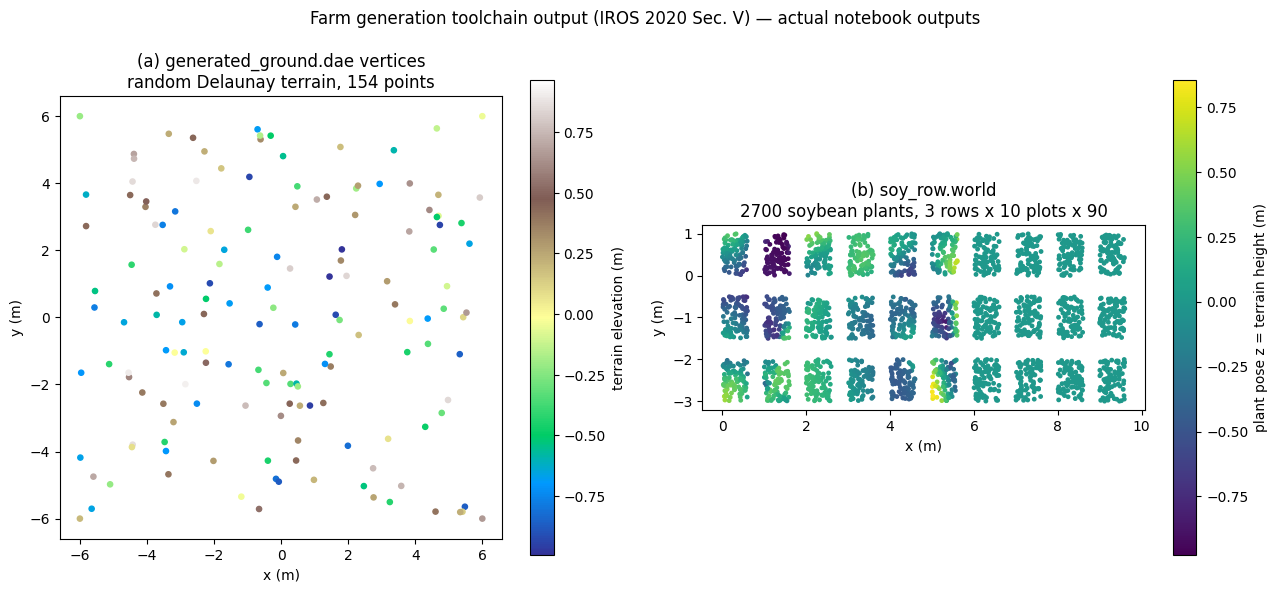

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))

# (a) generated ground vertices colored by elevation (connectivity malformed, see above)
mesh = Collada("/content/farm_gen/generated_ground.dae")
triset = mesh.geometries[0].primitives[0]
verts = np.array(triset.vertex)
pc = axes[0].scatter(verts[:, 0], verts[:, 1], c=verts[:, 2], s=14, cmap="terrain")
plt.colorbar(pc, ax=axes[0], label="terrain elevation (m)")
axes[0].set_title("(a) generated_ground.dae vertices\nrandom Delaunay terrain, 154 points")
axes[0].set_xlabel("x (m)"); axes[0].set_ylabel("y (m)"); axes[0].set_aspect("equal")

# (b) plant layout from soy_row.world, colored by terrain-adjusted pose Z
tree = ET.parse("/content/farm_gen/soy_row.world")
models = tree.getroot().findall("./world/model")
xyz = np.array([[float(v) for v in m.find("pose").text.split()[:3]] for m in models])
sc = axes[1].scatter(xyz[:, 0], xyz[:, 1], c=xyz[:, 2], s=6, cmap="viridis")
plt.colorbar(sc, ax=axes[1], label="plant pose z = terrain height (m)")
axes[1].set_title("(b) soy_row.world\n2700 soybean plants, 3 rows x 10 plots x 90")
axes[1].set_xlabel("x (m)"); axes[1].set_ylabel("y (m)"); axes[1].set_aspect("equal")

fig.suptitle("Farm generation toolchain output (IROS 2020 Sec. V) — actual notebook outputs", y=1.02)
fig.tight_layout()
fig.savefig("/content/farm_gen/farm_generation_result.png", dpi=120, bbox_inches="tight")
plt.show()

### Export a small results table

We summarize the three validated artifacts and key statistics into a CSV inside the Colab
filesystem for the learner to download. Expected result: a table with one row per artifact and a
printed preview.

In [ ]:
import pandas as pd

summary = pd.DataFrame([
    {"artifact": "soy_row.world", "content": "Gazebo SDF world", "records": 2700,
     "statistic": "unique plant models (3 rows x 10 plots x 90)"},
    {"artifact": "simulated_heights.csv", "content": "per-plot plant heights", "records": 2700,
     "statistic": f"mean {heights.mean():.3f} m, range [{heights.min():.3f}, {heights.max():.3f}] m"},
    {"artifact": "generated_ground.dae", "content": "COLLADA terrain mesh", "records": verts.shape[0],
     "statistic": f"vertices; Z range [{verts[:,2].min():.3f}, {verts[:,2].max():.3f}] m; "
                  f"author-script triangle-index defect documented"},
])
summary.to_csv("/content/farm_gen/validation_summary.csv", index=False)
summary

,artifact,content,records,statistic
0,soy_row.world,Gazebo SDF world,2700,unique plant models (3 rows x 10 plots x 90)
1,simulated_heights.csv,per-plot plant heights,2700,"mean 0.602 m, range [0.420, 0.780] m"
2,generated_ground.dae,COLLADA terrain mesh,154,"vertices; Z range [-0.992, 0.966] m; author-sc..."


## Interpretation and limitations

**What was reproduced.** The paper's Section V generator, run unmodified from the pinned commit,
produces all three released artifacts: a randomized Delaunay ground mesh (`.dae`), a Gazebo world
with 2700 uniquely named, randomly scaled (0.7–1.3), randomly yaw-rotated soybean models whose
poses sit on the interpolated terrain, and a per-plot simulated-height CSV (30 plots × 90 plants,
0.42–0.78 m given the 0.6 m model height and the chosen scale range). This matches the paper's
description of random ground creation (Sec. V-A) and plot generation (Sec. V-B).

**Differences from the paper's experiments.** The paper's simulated farms used the commercial
TurboSquid soybean models and unspecified plot geometry; those meshes are not redistributable and
the released dataset link is dead (HTTP 404), so placeholder URIs and operator-chosen geometry
are used. Terrain Z uses `np.random` which the authors' script does not seed, so exact elevation
values differ between runs while the seeded plant layout statistics are stable. We also
documented a defect in the authors' script: the written `.dae` triangle-index array is malformed
(interleaved vertex-index / `4*i` values), so mesh connectivity cannot be rendered from the file
as-is; vertex coordinates are valid. The LiDAR height-estimation pipeline (Sections IV and VI) is
**not** reproduced: it requires ROS/PCL C++ and the released scan datasets, which are unreachable.

**Provenance.** Author code: `hsd1121/PointCloudProcessing` @ `b31a54c8dc0b29ecd9aa35df3a6624ef6106eca7`
(`Python Scripts/farm_generation.py`, fetched pinned in cell 4). Paper: arXiv:1910.14031v3 /
IROS 2020 DOI 10.1109/IROS45743.2020.9341343. This notebook is an AI-assisted reproduction of
one subsection; a single generated farm does not verify the paper's dataset-level results.

日本語: 著者のスクリプトを改変せず実行し、3 種類の出力（地形メッシュ、Gazebo ワールド 2700 株、
小区画別草高 CSV）を検証しました。商用モデルとデータセットは入手不能のため、プレースホルダ URI と
作業者選定の幾何パラメータを使用しています。LiDAR による草高推定パイプラインは未再現です。